In [1]:
%run setup.py
mdates.set_epoch('2025-01-01')
from import_data import get_data


In [2]:
filenames = ['case2/cyclus.sqlite']

In [3]:
# list all unphysical commodities that should be ignored
ignore_commods = ['fluorine', 'oxygen', 'extra_fluorine', 'extra_oxygen', 'silica']

In [4]:
data = {}
for file in filenames:
    (name, file_data) = get_data(file, ignore_commods)
    
    print(name)
    
    data[name] = file_data

if len(data.keys()) == 1:
    data = data[list(data.keys())[0]]

case2


In [5]:
data['transactions']['Date'] = mdates.num2date(data['transactions']['Time'])

In [6]:
data['transactions'].columns

Index(['SimId', 'ResourceId', 'ObjId', 'Type', 'TimeCreated', 'Quantity',
       'Units', 'QualId', 'PackageName', 'Parent1', 'Parent2', 'TransactionId',
       'SenderId', 'ReceiverId', 'Commodity', 'Time', 'SenderSpec',
       'SenderPrototype', 'ReceiverSpec', 'ReceiverPrototype',
       'SenderProtAgentId', 'ReceiverProtAgentId', 'CumQuantityReceived',
       'CumQuantitySent', 'Date'],
      dtype='object')

In [7]:
data['agents']

,SimId,AgentId,Kind,Spec,Prototype,ParentId,Lifetime,EnterTime,ExitTime
0,4080a41d-390d-48d6-bf2d-c0149dd14437,567,Region,:agents:NullRegion,StateCase1,-1,-1,0,730.0
1,4080a41d-390d-48d6-bf2d-c0149dd14437,568,Inst,:agents:NullInst,Inst,567,-1,0,730.0
2,4080a41d-390d-48d6-bf2d-c0149dd14437,569,Facility,:cycamore:Sink,ForeignUF6Receiver,568,-1,0,730.0
3,4080a41d-390d-48d6-bf2d-c0149dd14437,570,Facility,:cycamore:Sink,ForeignUO2Receiver,568,-1,0,730.0
4,4080a41d-390d-48d6-bf2d-c0149dd14437,571,Facility,:cycamore:Source,ForeignFreshFuelShipper,568,-1,0,730.0
5,4080a41d-390d-48d6-bf2d-c0149dd14437,572,Facility,:cycamore:Source,Mill,568,-1,0,730.0
6,4080a41d-390d-48d6-bf2d-c0149dd14437,573,Facility,:cycamore:Storage,ConversionReciever,568,-1,0,730.0
7,4080a41d-390d-48d6-bf2d-c0149dd14437,574,Facility,:cycamore:Separations,ConversionU,568,-1,0,730.0
8,4080a41d-390d-48d6-bf2d-c0149dd14437,575,Facility,:cycamore:Mixer,ConversionUF6Mixer,568,-1,0,730.0
9,4080a41d-390d-48d6-bf2d-c0149dd14437,576,Facility,:cycamore:Storage,ConversionShipper,568,-1,0,730.0


In [8]:
data['transactions'] = data['transactions'].merge(data['agents'],how='left',left_on=['SimId','SenderPrototype'],right_on=['SimId','Prototype']).drop(columns=['Prototype','Kind']).rename(columns={'Spec':'SenderSpec'})
data['transactions'] = data['transactions'].merge(data['agents'],how='left',left_on=['SimId','ReceiverPrototype'],right_on=['SimId','Prototype']).drop(columns=['Prototype','Kind']).rename(columns={'Spec':'ReceiverSpec'})

In [9]:
data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'][0:10]

,SimId,AgentId,Kind,Spec,Prototype,ParentId,Lifetime,EnterTime,ExitTime
21,4080a41d-390d-48d6-bf2d-c0149dd14437,613,Facility,:cycamore:Reactor,Rx_B1_Reactor,586,-1,27,730.0
24,4080a41d-390d-48d6-bf2d-c0149dd14437,616,Facility,:cycamore:Reactor,Rx_B2_Reactor,586,-1,66,730.0
27,4080a41d-390d-48d6-bf2d-c0149dd14437,619,Facility,:cycamore:Reactor,Rx_B3_Reactor,586,-1,106,730.0
30,4080a41d-390d-48d6-bf2d-c0149dd14437,622,Facility,:cycamore:Reactor,Rx_B4_Reactor,586,-1,147,730.0
33,4080a41d-390d-48d6-bf2d-c0149dd14437,625,Facility,:cycamore:Reactor,Rx_B5_Reactor,586,-1,197,730.0
36,4080a41d-390d-48d6-bf2d-c0149dd14437,628,Facility,:cycamore:Reactor,Rx_B6_Reactor,586,-1,237,730.0
39,4080a41d-390d-48d6-bf2d-c0149dd14437,631,Facility,:cycamore:Reactor,Rx_B7_Reactor,586,-1,307,730.0
42,4080a41d-390d-48d6-bf2d-c0149dd14437,634,Facility,:cycamore:Reactor,Rx_B8_Reactor,586,-1,350,730.0


In [10]:
data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor']['Prototype'].iloc[0]

'Rx_B1_Reactor'

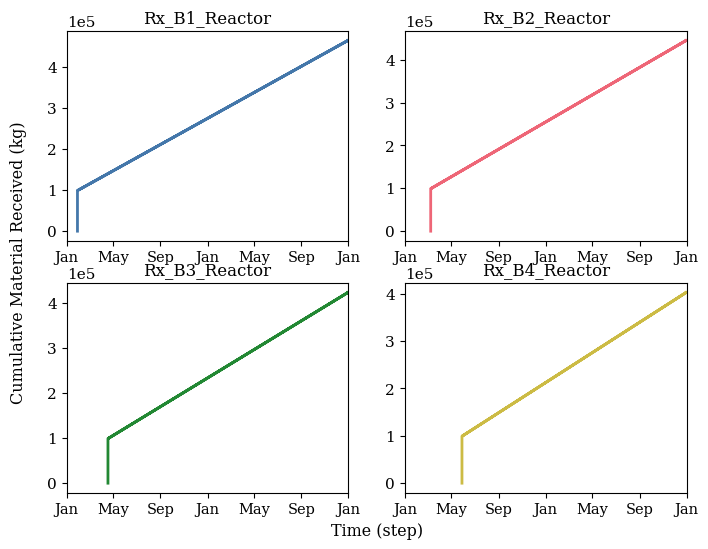

In [17]:
fig = plt.figure(figsize = (8, 6))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='w', top= False, bottom= False, left= False, right= False)

ax0 = fig.add_subplot(221)
ax0.set_xlim([00,730])
ax0.step(data['transactions'].loc[data['transactions']['ReceiverPrototype'] == data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'].iloc[0]['Prototype']]['Time'],
         data['transactions'].loc[data['transactions']['ReceiverPrototype'] == data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'].iloc[0]['Prototype']]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'].iloc[0]['Prototype'])
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,2))
ax0.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax0 = fig.add_subplot(222)
ax0.set_xlim([00,730])
ax0.step(data['transactions'].loc[data['transactions']['ReceiverPrototype'] == data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'].iloc[1]['Prototype']]['Time'],
         data['transactions'].loc[data['transactions']['ReceiverPrototype'] == data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'].iloc[1]['Prototype']]['CumQuantityReceived'],
         color= palette[1])
ax0.set_title(data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'].iloc[1]['Prototype'])
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,2))
ax0.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax0 = fig.add_subplot(223)
ax0.set_xlim([00,730])
ax0.step(data['transactions'].loc[data['transactions']['ReceiverPrototype'] == data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'].iloc[2]['Prototype']]['Time'],
         data['transactions'].loc[data['transactions']['ReceiverPrototype'] == data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'].iloc[2]['Prototype']]['CumQuantityReceived'],
         color= palette[2])
ax0.set_title(data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'].iloc[2]['Prototype'])
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,2))
ax0.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax0 = fig.add_subplot(224)
ax0.set_xlim([00,730])
ax0.step(data['transactions'].loc[data['transactions']['ReceiverPrototype'] == data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'].iloc[3]['Prototype']]['Time'],
         data['transactions'].loc[data['transactions']['ReceiverPrototype'] == data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'].iloc[3]['Prototype']]['CumQuantityReceived'],
         color= palette[3])
ax0.set_title(data['agents'].loc[data['agents']['Spec'] == ':cycamore:Reactor'].iloc[3]['Prototype'])
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,2))
ax0.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
